In [1]:
# ===================== Cell A: Config =====================
import os, glob, random, gzip, shutil
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers.legacy import Adam

import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)          # Python's random — your BUSISequence uses this
np.random.seed(SEED)       # NumPy — your augmentation + shuffling use this
tf.random.set_seed(SEED)   # TensorFlow — weight init, dropout
BUSI_ROOT = "/Users/mariyamafnan/Documents/MVI/Dataset_BUSI_with_GT"
IMG_SIZE = 256                                 # must be divisible by 16
CLASSES = ['benign', 'malignant', 'normal']
TEST_RATIO = {'benign': 9, 'malignant': 4}      # normal NOT in test set                                    # -> 108 benign, 48 malignant
KEEP_NORMAL_IN_TRAIN = False                   
BATCH_SIZE = 2                                  # raise to 4 if memory allows (halves epoch time)
AUGMENT_FACTOR = 2
TEST_SPLIT_SEED = 42

In [2]:
# ===================== Cell B: Data utilities =====================
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def find_busi_pairs(root_dir):
    rows = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        imgs = [p for p in sorted(glob.glob(os.path.join(cls_dir, '*.png')))
                if '_mask' not in os.path.basename(p)]
        for img_path in imgs:
            masks = sorted(glob.glob(os.path.splitext(img_path)[0] + '_mask*.png'))
            if masks:
                rows.append({'image': img_path, 'masks': masks, 'class': cls})
    return pd.DataFrame(rows)

def robust_imread_gray(path):
    # 1) OpenCV
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None: return img
    except Exception: pass
    # 2) PIL
    try:
        return np.array(Image.open(path).convert('L'))
    except Exception: pass
    # 3) imageio
    try:
        import imageio.v2 as imageio
        arr = imageio.imread(path)
        if arr.ndim == 3: arr = arr[..., 0]
        return np.asarray(arr, dtype=np.uint8)
    except Exception: pass
    # 4) scikit-image
    try:
        from skimage.io import imread as sk_imread
        arr = sk_imread(path, as_gray=True)
        return (arr * 255).astype(np.uint8) if arr.max() <= 1.0 else arr.astype(np.uint8)
    except Exception: pass
    raise ValueError(f"ALL 4 readers failed for: {path}")

def merge_masks(mask_paths):
    combined = None
    for mp in mask_paths:
        m = robust_imread_gray(mp)
        m = (m > 127).astype(np.uint8)
        combined = m if combined is None else np.maximum(combined, m)
    return combined

def resize_with_padding(arr, size=IMG_SIZE, is_mask=False):
    h, w = arr.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(round(h*scale)), int(round(w*scale))
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
    resized = cv2.resize(arr, (nw, nh), interpolation=interp)
    canvas = np.zeros((size, size), dtype=arr.dtype)
    top, left = (size-nh)//2, (size-nw)//2
    canvas[top:top+nh, left:left+nw] = resized
    return canvas

def load_pair(row, size=IMG_SIZE):
    img = robust_imread_gray(row['image'])
    mask = merge_masks(row['masks'])
    img = resize_with_padding(img, size)
    mask = resize_with_padding(mask, size, is_mask=True)
    return img.astype(np.float32)[..., None]/255.0, mask.astype(np.float32)[..., None]

In [3]:
# ===================== Cell D: Augmentation + Sequence =====================
# ===================== Cell D (fixed): size passed explicitly =====================
from scipy.ndimage import gaussian_filter, map_coordinates

def elastic_transform(img, mask, alpha=40, sigma=6):
    shape = img.shape[:2]
    dx = gaussian_filter((np.random.rand(*shape)*2 - 1), sigma) * alpha
    dy = gaussian_filter((np.random.rand(*shape)*2 - 1), sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    coords = [np.clip(y+dy, 0, shape[0]-1).ravel(), np.clip(x+dx, 0, shape[1]-1).ravel()]
    im = map_coordinates(img[..., 0],  coords, order=1).reshape(shape)
    mk = map_coordinates(mask[..., 0], coords, order=0).reshape(shape)
    return im[..., None].astype(np.float32), (mk > 0.5)[..., None].astype(np.float32)

def augment_pair(img, mask, rng, size):
    # ---- geometric: apply to BOTH ----
    if rng.random() < 0.5: img, mask = np.fliplr(img), np.fliplr(mask)
    if rng.random() < 0.5: img, mask = np.flipud(img), np.flipud(mask)

    angle = rng.uniform(-20, 20); scale = rng.uniform(0.85, 1.15)
    M = cv2.getRotationMatrix2D((size/2, size/2), angle, scale)
    img  = cv2.warpAffine(img,  M, (size, size), flags=cv2.INTER_AREA,   borderMode=cv2.BORDER_CONSTANT)
    mask = cv2.warpAffine(mask, M, (size, size), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    if img.ndim == 2:  img  = img[..., None]
    if mask.ndim == 2: mask = mask[..., None]
    img = img.astype(np.float32)

    # ---- elastic deformation (medical-imaging augmentation) ----
    if rng.random() < 0.2:
        img, mask = elastic_transform(img, mask, alpha=40, sigma=6)

    # ---- intensity: IMAGE only ----
    if rng.random() < 0.4:                       # brightness
        img = np.clip(img * rng.uniform(0.9, 1.1), 0, 1)
    if rng.random() < 0.3:                        # contrast
        mn = img.mean(); img = np.clip((img-mn)*rng.uniform(0.9, 1.1)+mn, 0, 1)
    if rng.random() < 0.15:                        # random gamma
        img = np.clip(img ** rng.uniform(0.7, 1.5), 0, 1)
    if rng.random() < 0.10:                       # light speckle noise
        img = np.clip(img + img*0.05*np.random.randn(*img.shape), 0, 1)

    return img.astype(np.float32), (mask > 0.5).astype(np.float32)

class BUSISequence(keras.utils.Sequence):
    _cache = {}   # shared across all instances, keyed by (path, size)
    def __init__(self, df, batch_size=BATCH_SIZE, augment=False, augment_factor=1,
                 shuffle=True, seed=42, img_size=None):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.augment_factor = augment_factor if augment else 1
        self.shuffle = shuffle
        self.img_size = img_size if img_size is not None else IMG_SIZE
        self.rng = random.Random(seed)
        # preload all pairs into memory once (cached by path+size, reused across folds)
        self.pairs = []
        for _, row in self.df.iterrows():
            key = (row['image'], self.img_size)
            if key not in BUSISequence._cache:
                BUSISequence._cache[key] = load_pair(row, size=self.img_size)
            self.pairs.append(BUSISequence._cache[key])
        self.indices = np.repeat(np.arange(len(self.df)), self.augment_factor)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.RandomState(self.rng.randint(0, 1 << 30)).shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, masks = [], []
        for i in batch_idx:
            img, mask = self.pairs[i]
            if self.augment:
                img, mask = augment_pair(img.copy(), mask.copy(), self.rng, self.img_size)
            imgs.append(img); masks.append(mask)
        return np.stack(imgs), np.stack(masks)

In [4]:
# ===================== Cell E: Load data =====================
df = find_busi_pairs(BUSI_ROOT)
df = df[df['class'] != 'normal'].reset_index(drop=True)   # remove this line if keeping normal
print(f"Images: {len(df)}")


Images: 647


In [5]:
# ===================== FULL CURATION (self-contained): sim + axilla + dedup + split =====================
import os

# ---- compute similarity matrix ----
names = [os.path.basename(p) for p in df['image']]
_vecs = []
for p in df['image']:
    im = cv2.resize(robust_imread_gray(p), (64, 64)).astype(np.float32)
    im = (im - im.mean()) / (im.std() + 1e-6)
    _vecs.append(im.flatten())
mat = np.stack(_vecs)
mat = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-6)
sim = mat @ mat.T

# ---- axilla images (manually verified) ----
AXILLA_MANUAL = [
    "benign (199).png", "benign (205).png", "benign (207).png", "benign (210).png",
    "benign (223).png", "benign (225).png", "benign (228).png","benign (416).png", "benign (235).png",
    "benign (236).png", "benign (243).png", "benign (247).png", "benign (248).png",
    "benign (256).png", "benign (257).png", "benign (262).png", "benign (292).png",
    "benign (293).png", "benign (294).png", "benign (298).png", "benign (306).png",
    "malignant (11).png", "malignant (12).png", "malignant (13).png", "malignant (109).png",
    "malignant (110).png", "malignant (113).png", "malignant (148).png",
]
axilla = set(AXILLA_MANUAL)
print(f"Excluding {len(axilla)} manually-verified axilla images")

THRESH = 0.886
# ---- dedup (threshold 0.886 + manual overrides) ----
MANUAL_DUP = [
    ("benign (201).png", "benign (302).png"),
    ("malignant (7).png", "malignant (8).png"),
    ("malignant (8).png", "malignant (9).png"),
    ("benign (64).png", "benign (141).png"),
]
MANUAL_KEEP = [
    ("malignant (3).png", "malignant (7).png"),
    ("malignant (24).png", "malignant (25).png"),
    ("malignant (28).png", "malignant (119).png", "benign (119).png"),
]
# images wrongly flagged as duplicates by the threshold — force-keep them
FORCE_KEEP = {
    "malignant (50).png", "malignant (72).png",
    "malignant (40).png", "malignant (6).png",
    "benign (435).png", "malignant (4).png"                         
}

keep_apart = {frozenset(p) for p in MANUAL_KEEP}
parent = {n: n for n in names}
def find(x):
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    if a in parent and b in parent: parent[find(a)] = find(b)

for i in range(len(names)):
    for j in range(i+1, len(names)):
        if sim[i, j] > THRESH and frozenset({names[i], names[j]}) not in keep_apart:
            union(names[i], names[j])
for a, b in MANUAL_DUP:
    union(a, b)

groups = {}
for n in names: groups.setdefault(find(n), []).append(n)
keep_dedup = {sorted(g)[0] for g in groups.values()}

# ---- final: deduped minus axilla ----
keep = keep_dedup - axilla
print(f"{len(names)} -> {len(keep)} after curation "
      f"({len(names)-len(keep_dedup)} dups + {len(keep_dedup & axilla)} axilla removed)")

df = df[df['image'].apply(lambda p: os.path.basename(p) in keep)].reset_index(drop=True)
print(df['class'].value_counts().to_string())

Excluding 28 manually-verified axilla images
647 -> 509 after curation (117 dups + 21 axilla removed)
class
benign       329
malignant    180


In [6]:
# ===================== Cell C2: 80/20 split (test always tumor-only) =====================
from sklearn.model_selection import train_test_split

tumor_df  = df[df['class'] != 'normal'].reset_index(drop=True)
normal_df = df[df['class'] == 'normal'].reset_index(drop=True)   # empty if the load cell dropped normals

# split TUMOR 80/20 — test can only ever be tumor
tumor_trainval, test_df = train_test_split(tumor_df, test_size=0.20, stratify=tumor_df['class'], random_state=SEED)
test_df = test_df.reset_index(drop=True)

# add whatever normals are already in df to TRAINING only (none if you excluded them upstream)
trainval_df = pd.concat([tumor_trainval, normal_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Train/val: {len(trainval_df)}  ({len(tumor_trainval)} tumor + {len(normal_df)} normal)")
print(f"Held-out TEST (tumor only): {len(test_df)}")
print("Test class counts:\n" + test_df['class'].value_counts().to_string())

Train/val: 407  (407 tumor + 0 normal)
Held-out TEST (tumor only): 102
Test class counts:
class
benign       66
malignant    36


In [7]:
# ===================== Cell F: Loss & metrics =====================
def dice_coef(y_true, y_pred, smooth=1e-6):
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt * yp)
    return (2. * inter + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def hybrid_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * tf.reduce_mean(bce) + 0.5 * dice_loss(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-6):
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt * yp)
    return (inter + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter + smooth)

def numpy_dice(y_true, y_pred, smooth=1e-6):
    yt = y_true.flatten(); yp = (y_pred > 0.5).astype(np.float32).flatten()
    inter = np.sum(yt * yp)
    return (2*inter + smooth) / (np.sum(yt) + np.sum(yp) + smooth)

def numpy_iou(y_true, y_pred, smooth=1e-6):
    yt = y_true.flatten(); yp = (y_pred > 0.5).astype(np.float32).flatten()
    inter = np.sum(yt * yp)
    return (inter + smooth) / (np.sum(yt) + np.sum(yp) - inter + smooth)

In [8]:
# ===================== Cell G: Architecture =====================
def eca_channel_gate(x, k_size=3):
    c = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((c, 1))(gap)
    gap = layers.Conv1D(1, kernel_size=k_size, padding='same', use_bias=False)(gap)
    gap = layers.Activation('sigmoid')(gap)
    gap = layers.Reshape((1, 1, c))(gap)
    return layers.Multiply()([x, gap])


def fused_attention_gate(x_skip, g, inter_channels):
    theta_x = layers.Conv2D(inter_channels, 1, padding='same')(x_skip)
    phi_g = layers.Conv2D(inter_channels, 1, padding='same')(g)
    add_xg = layers.Activation('relu')(layers.Add()([theta_x, phi_g]))
    psi = layers.Conv2D(1, 1, padding='same',
                        bias_initializer=keras.initializers.Constant(-2.0))(add_xg)
    alpha = layers.Activation('sigmoid')(psi)
    spatial_gated = layers.Multiply()([x_skip, alpha])
    channel_gated = eca_channel_gate(spatial_gated)
    return layers.Add()([channel_gated, x_skip])


def vnet_residual_block(x, filters, activation='relu', dropout=0.1, dilation_rate=1):
    shortcut = x
    y = layers.Conv2D(filters, 3, padding='same', activation=activation, dilation_rate=dilation_rate)(x)
    y = layers.Conv2D(filters, 3, padding='same', dilation_rate=dilation_rate)(y)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    y = layers.Activation(activation)(layers.Add()([y, shortcut]))
    return layers.Dropout(dropout)(y) if dropout > 0 else y


def vnet_downsample(x, filters):
    return layers.Conv2D(filters, 2, strides=2, padding='same', activation='relu')(x)


def aspp_block(x, filters, rates=(1, 2, 4, 8)):
    branches = [layers.Conv2D(filters, 3, padding='same', dilation_rate=r, activation='relu')(x)
                for r in rates]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, x.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation='bilinear')(gap)
    branches.append(gap)
    return layers.Conv2D(filters, 1, padding='same', activation='relu')(layers.Concatenate()(branches))


def build_innovation_unet(input_size=(IMG_SIZE, IMG_SIZE, 1), base_filters=None,
                          enc=None, bottleneck=None, dec=None, dropout=0.1, lr=1e-4):
    if base_filters is not None and enc is None:
        enc = (base_filters, base_filters * 2, base_filters * 4, base_filters * 8)
        bottleneck = base_filters * 16
        dec = (base_filters * 8, base_filters * 4, base_filters * 2, base_filters)
    f1, f2, f3, f4 = enc
    g4, g3, g2, g1 = dec

    inputs = layers.Input(input_size)
    e1 = vnet_residual_block(inputs, f1, dropout=dropout)
    d1 = vnet_downsample(e1, f2)
    e2 = vnet_residual_block(d1, f2, dropout=dropout)
    d2 = vnet_downsample(e2, f3)
    e3 = vnet_residual_block(d2, f3, dropout=dropout)
    d3 = vnet_downsample(e3, f4)
    e4 = vnet_residual_block(d3, f4, dropout=dropout, dilation_rate=2)
    d4 = vnet_downsample(e4, bottleneck)

    b = aspp_block(d4, bottleneck, rates=(1, 2, 4, 8))
    b = layers.Dropout(dropout)(b)

    u4 = layers.Conv2DTranspose(g4, 2, strides=2, padding='same')(b)
    u4 = layers.Concatenate()([u4, fused_attention_gate(e4, u4, g4)])
    u4 = vnet_residual_block(u4, g4, dropout=dropout)
    u3 = layers.Conv2DTranspose(g3, 2, strides=2, padding='same')(u4)
    u3 = layers.Concatenate()([u3, fused_attention_gate(e3, u3, g3)])
    u3 = vnet_residual_block(u3, g3, dropout=dropout)
    u2 = layers.Conv2DTranspose(g2, 2, strides=2, padding='same')(u3)
    u2 = layers.Concatenate()([u2, fused_attention_gate(e2, u2, g2)])
    u2 = vnet_residual_block(u2, g2, dropout=dropout)
    u1 = layers.Conv2DTranspose(g1, 2, strides=2, padding='same')(u2)
    u1 = layers.Concatenate()([u1, fused_attention_gate(e1, u1, g1)])
    u1 = vnet_residual_block(u1, g1, dropout=dropout)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(u1)
    model = Model(inputs, outputs, name='innovation_vnet_unet_aspp')
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=hybrid_loss,
                  metrics=[dice_coef, iou_coef])
    return model

# ===================== Cell K: MealPy tuning (SMA, size-penalised, no hard cap) =====================
from mealpy import FloatVar
from mealpy.bio_based.SMA import OriginalSMA
from sklearn.model_selection import StratifiedKFold
import gc

K_TUNE       = 5
PROXY_EPOCHS = 10
MAX_PARAMS = 2_033_025     # benchmark params — penalty = fraction of benchmark size
LAMBDA     = 0.15          # with the raised floor bounds this won't collapse to a tiny model 
DICE_FLOOR   = 0.40

inner_skf = StratifiedKFold(n_splits=K_TUNE, shuffle=True, random_state=SEED)
folds = list(inner_skf.split(trainval_df.index, trainval_df['class']))

trials, best_seen = [], {'fit': 1e9}
def evaluate(sol):
    f = [max(8, int(round(v/8))*8) for v in sol[:5]]
    dropout = float(sol[5]); lr = 10**float(sol[6])
    enc=(f[0],f[1],f[2],f[3]); bottleneck=f[4]; dec=(f[3],f[2],f[1],f[0])
    fold_dice, params = [], None
    for k, (tr, va) in enumerate(folds, 1):
        tg = BUSISequence(trainval_df.iloc[tr].reset_index(drop=True), batch_size=BATCH_SIZE, augment=True,  augment_factor=1, shuffle=True,  img_size=IMG_SIZE)
        vg = BUSISequence(trainval_df.iloc[va].reset_index(drop=True), batch_size=BATCH_SIZE, augment=False,                    shuffle=False, img_size=IMG_SIZE)
        keras.backend.clear_session(); gc.collect(); tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)
        try:
            m = build_innovation_unet(enc=enc, bottleneck=bottleneck, dec=dec, dropout=dropout, lr=lr)
            params = m.count_params()
            h = m.fit(tg, validation_data=vg, epochs=PROXY_EPOCHS,
                      callbacks=[keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=3, restore_best_weights=True)], verbose=0)
            fold_dice.append(float(max(h.history['val_dice_coef'])))
            print(f"   fold {k}/{K_TUNE} dice={fold_dice[-1]:.4f}", flush=True)
        except (tf.errors.ResourceExhaustedError, tf.errors.InternalError, MemoryError):
            keras.backend.clear_session(); print(f"{f} -> OOM", flush=True); return 10.0
    mean_dice = float(np.mean(fold_dice))
    fitness = (1 - mean_dice) + LAMBDA*(params/MAX_PARAMS) + max(0.0, DICE_FLOOR - mean_dice)*5
    trials.append({'f': f, 'dropout': round(dropout,3), 'lr': lr, 'cv_dice': round(mean_dice,4), 'params': params, 'fit': round(fitness,5)})
    if fitness < best_seen['fit']:
        best_seen.update(fit=fitness, f=f, dropout=dropout, lr=lr, dice=mean_dice, params=params)
    print(f"f={f} drop={dropout:.2f} lr={lr:.1e} CVdice={mean_dice:.4f} params={params:,} fit={fitness:.5f}"
          f"{'  <-- best' if fitness==best_seen['fit'] else ''}\n", flush=True)
    return fitness

problem = {"bounds": FloatVar(lb=(16,24,48,56,64, 0.10, -4.0), ub=(24,48,96,96,112, 0.35, -3.0), name="hp"),
           "minmax": "min", "obj_func": evaluate}
best = OriginalSMA(epoch=4, pop_size=5).solve(problem)

print("\n===== BEST (hardwire into training cell) =====")
print(f"enc={tuple(best_seen['f'][:4])}  bottleneck={best_seen['f'][4]}  dec={tuple(best_seen['f'][:4][::-1])}")
print(f"dropout={best_seen['dropout']:.4f}  lr={best_seen['lr']:.6f}  (CV dice={best_seen['dice']:.4f}, params={best_seen['params']:,})")

In [53]:
# SMA candidate — highest real CV dice in the sub-1M band, good prune headroom
enc = (16, 40, 48, 56)
bottleneck = 104
dec = (56, 48, 40, 16)        # reverse of enc
best_dropout = 0.16
best_lr = 2.7e-4
DROPOUT, LR = best_dropout, best_lr

tvs = trainval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
nv = int(len(tvs) * 0.15)
tg = BUSISequence(tvs.iloc[nv:], batch_size=BATCH_SIZE, augment=True, augment_factor=AUGMENT_FACTOR, shuffle=True,
                  img_size=IMG_SIZE)
vg = BUSISequence(tvs.iloc[:nv], batch_size=BATCH_SIZE, augment=False, shuffle=False, img_size=IMG_SIZE)

keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)
final_model = build_innovation_unet(enc=enc, bottleneck=bottleneck, dec=dec, dropout=DROPOUT, lr=LR)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', mode='max',
                                      factor=0.5, patience=5, min_delta=0.003, cooldown=2, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max',
                                  patience=15, start_from_epoch=40, restore_best_weights=True),
]
final_model.fit(tg, validation_data=vg, epochs=80, callbacks=callbacks, verbose=1)
final_model.save("innovation_seed42_final.keras")
print(f"Final params: {final_model.count_params():,}")

def tta_predict(model, img):
    v = [img, np.fliplr(img), np.flipud(img), np.fliplr(np.flipud(img))]
    p = [model.predict(x[None, ...], verbose=0)[0][..., 0] for x in v]
    p[1] = np.fliplr(p[1]); p[2] = np.flipud(p[2]); p[3] = np.flipud(np.fliplr(p[3]))
    return np.mean(p, axis=0)

rows = []
for _, r in test_df.iterrows():
    img, mask = load_pair(r)
    rows.append({'filename': os.path.basename(r['image']), 'class': r['class'],
                 'dice': numpy_dice(mask[..., 0], (tta_predict(final_model, img) > 0.5).astype(np.float32))})
rt = pd.DataFrame(rows)
print(f"\n===== HELD-OUT TEST (n={len(rt)}): mean={rt['dice'].mean():.4f} median={rt['dice'].median():.4f} "
      f">=0.85={(rt['dice'] >= 0.85).sum()}/{len(rt)} <0.5={(rt['dice'] < 0.5).sum()} =====")
print(rt.groupby('class')['dice'].mean().round(4).to_string())
rt.to_csv("per_image_seed42_final_test.csv", index=False)

Epoch 1/80


2026-09-14 01:01:29.359330: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


346/346 [==============================] - ETA: 0s - loss: 0.5341 - dice_coef: 0.2202 - iou_coef: 0.1345

2026-09-14 01:03:32.214163: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


346/346 [==============================] - 135s 263ms/step - loss: 0.5341 - dice_coef: 0.2202 - iou_coef: 0.1345 - val_loss: 0.3985 - val_dice_coef: 0.3999 - val_iou_coef: 0.2645 - lr: 2.7000e-04
Epoch 2/80
346/346 [==============================] - 64s 183ms/step - loss: 0.4151 - dice_coef: 0.4100 - iou_coef: 0.2744 - val_loss: 0.3301 - val_dice_coef: 0.5157 - val_iou_coef: 0.3757 - lr: 2.7000e-04
Epoch 3/80
346/346 [==============================] - 66s 191ms/step - loss: 0.3604 - dice_coef: 0.4817 - iou_coef: 0.3389 - val_loss: 0.3120 - val_dice_coef: 0.5346 - val_iou_coef: 0.3943 - lr: 2.7000e-04
Epoch 4/80
346/346 [==============================] - 71s 203ms/step - loss: 0.3390 - dice_coef: 0.5170 - iou_coef: 0.3733 - val_loss: 0.3105 - val_dice_coef: 0.5318 - val_iou_coef: 0.3914 - lr: 2.7000e-04
Epoch 5/80
346/346 [==============================] - 66s 190ms/step - loss: 0.3230 - dice_coef: 0.5396 - iou_coef: 0.3962 - val_loss: 0.3675 - val_dice_coef: 0.4855 - val_iou_coef: 0.34

2026-09-14 02:19:11.671466: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



===== HELD-OUT TEST (n=102): mean=0.7962 median=0.8749 >=0.85=57/102 <0.5=10 =====
class
benign       0.8288
malignant    0.7363


In [54]:
# ===================== Cell J: Evaluate unpruned on held-out test set =====================
def evaluate_model(model, tag):
    rows = []
    for _, row in test_df.iterrows():
        img, mask = load_pair(row)
        pred = tta_predict(model, img)[..., None]        # <-- TTA, matches pruned eval
        rows.append({'filename': os.path.basename(row['image']),
                     'class': row['class'],
                     'dice': numpy_dice(mask, pred),
                     'iou': numpy_iou(mask, pred),
                     'true_px': int(mask.sum()),
                     'pred_px': int((pred > 0.5).sum())})
    r = pd.DataFrame(rows).sort_values('dice').reset_index(drop=True)
    n = len(r)
    print(f"\n===== {tag} =====")
    print(f"Mean Dice   : {r['dice'].mean():.4f}")
    print(f"Median Dice : {r['dice'].median():.4f}")
    print(f"Mean IoU    : {r['iou'].mean():.4f}")
    print(f">= 0.85     : {(r['dice'] >= 0.85).sum()} / {n}")
    print(f">= 0.80     : {(r['dice'] >= 0.80).sum()} / {n}")
    print(f">= 0.70     : {(r['dice'] >= 0.70).sum()} / {n}")
    print(f"<  0.50     : {(r['dice'] <  0.50).sum()} / {n}")
    print(r.groupby('class')[['dice','iou']].mean())
    return r

res_unpruned = evaluate_model(final_model, "UNPRUNED")
res_unpruned.to_csv("per_image_seed42_unpruned.csv", index=False)


===== UNPRUNED =====
Mean Dice   : 0.7962
Median Dice : 0.8749
Mean IoU    : 0.6978
>= 0.85     : 57 / 102
>= 0.80     : 70 / 102
>= 0.70     : 83 / 102
<  0.50     : 10 / 102
               dice       iou
class                        
benign     0.828814  0.744274
malignant  0.736347  0.612469


In [74]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

In [75]:
# ===================== Structured pruning (magnitude filter masking) =====================
def structured_masks(model, sparsity=0.3):
    masks = {}
    for l in model.layers:
        if isinstance(l, layers.Conv2D) and not isinstance(l, layers.Conv2DTranspose) and l.get_weights():
            w = l.get_weights(); k = w[0]; oc = k.shape[-1]
            if oc <= 2: continue
            idx = np.argsort(np.sum(np.abs(k), axis=(0,1,2)))[:int(sparsity*oc)]
            mask = np.ones_like(k); mask[:, :, :, idx] = 0
            w[0] = k * mask
            if len(w) > 1: w[1][idx] = 0
            l.set_weights(w); masks[l.name] = mask
    return masks

class MaskEnforcer(keras.callbacks.Callback):
    def __init__(self, masks): super().__init__(); self.masks = masks
    def on_train_batch_end(self, batch, logs=None):
        for l in self.model.layers:
            if l.name in self.masks:
                w = l.get_weights(); w[0] = w[0]*self.masks[l.name]; l.set_weights(w)

tvs = trainval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
nv = int(len(tvs)*0.15)
ft_tg = BUSISequence(tvs.iloc[nv:], batch_size=BATCH_SIZE, augment=True,  augment_factor=1, shuffle=True,  img_size=IMG_SIZE)
ft_vg = BUSISequence(tvs.iloc[:nv], batch_size=BATCH_SIZE, augment=False,                    shuffle=False, img_size=IMG_SIZE)

struct_model = keras.models.clone_model(final_model)
struct_model.set_weights(final_model.get_weights())
masks = structured_masks(struct_model, sparsity=0.3)
struct_model.compile(optimizer=Adam(learning_rate=best_lr, clipnorm=1.0), loss=hybrid_loss, metrics=[dice_coef, iou_coef])
struct_model.fit(ft_tg, validation_data=ft_vg, epochs=5,
                 callbacks=[MaskEnforcer(masks)], verbose=1)
for l in struct_model.layers:
    if l.name in masks:
        w = l.get_weights(); w[0] = w[0]*masks[l.name]; l.set_weights(w)

total = zeros = 0
for l in struct_model.layers:
    if isinstance(l, layers.Conv2D) and not isinstance(l, layers.Conv2DTranspose) and l.get_weights():
        k = l.get_weights()[0]; total += k.size; zeros += int((k == 0).sum())
print(f"Structured sparsity: {100*zeros/total:.1f}%")

ds = []
for _, r in test_df.iterrows():
    img, mask = load_pair(r)
    ds.append(numpy_dice(mask[..., 0], (tta_predict(struct_model, img) > 0.5).astype(np.float32)))
ds = np.array(ds)
print(f"STRUCTURED+TTA: mean={ds.mean():.4f} median={np.median(ds):.4f} "
      f">=0.85={(ds>=0.85).sum()}/{len(ds)} <0.5={(ds<0.5).sum()}")
struct_model.save("innovation_seed42_structured.keras")

Epoch 1/5


2026-09-14 09:06:36.504512: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


173/173 [==============================] - ETA: 0s - loss: 0.2160 - dice_coef: 0.6890 - iou_coef: 0.5584

2026-09-14 09:08:26.818574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


173/173 [==============================] - 127s 511ms/step - loss: 0.2160 - dice_coef: 0.6890 - iou_coef: 0.5584 - val_loss: 0.2627 - val_dice_coef: 0.6521 - val_iou_coef: 0.5285
Epoch 2/5
173/173 [==============================] - 72s 415ms/step - loss: 0.1848 - dice_coef: 0.7488 - iou_coef: 0.6225 - val_loss: 0.2528 - val_dice_coef: 0.6715 - val_iou_coef: 0.5493
Epoch 3/5
173/173 [==============================] - 46s 262ms/step - loss: 0.1766 - dice_coef: 0.7586 - iou_coef: 0.6366 - val_loss: 0.2457 - val_dice_coef: 0.6905 - val_iou_coef: 0.5725
Epoch 4/5
173/173 [==============================] - 48s 273ms/step - loss: 0.1873 - dice_coef: 0.7447 - iou_coef: 0.6191 - val_loss: 0.2306 - val_dice_coef: 0.6881 - val_iou_coef: 0.5652
Epoch 5/5
173/173 [==============================] - 55s 315ms/step - loss: 0.1643 - dice_coef: 0.7702 - iou_coef: 0.6463 - val_loss: 0.2289 - val_dice_coef: 0.6849 - val_iou_coef: 0.5608
Structured sparsity: 29.4%


2026-09-14 09:12:20.885192: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


STRUCTURED+TTA: mean=0.7970 median=0.8840 >=0.85=59/102 <0.5=9


In [76]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

In [77]:

# ===================== Unstructured pruning (TFMOT) -> innovation_model_final =====================
import tensorflow_model_optimization as tfmot
PRUNE_EPOCHS = 5
prune_gen = BUSISequence(trainval_df, batch_size=BATCH_SIZE, augment=True, augment_factor=1, shuffle=True, img_size=IMG_SIZE)
end_step = len(prune_gen) * PRUNE_EPOCHS
pruning_params = {'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0, final_sparsity=0.3, begin_step=0, end_step=end_step)}

pm = tfmot.sparsity.keras.prune_low_magnitude(struct_model, **pruning_params)   # <-- back to the whole-model call
pm.compile(optimizer=Adam(learning_rate=best_lr, clipnorm=1.0), loss=hybrid_loss, metrics=[dice_coef, iou_coef])
pm.fit(prune_gen, epochs=PRUNE_EPOCHS, callbacks=[tfmot.sparsity.keras.UpdatePruningStep()], verbose=1)

innovation_model_final = tfmot.sparsity.keras.strip_pruning(pm)
innovation_model_final.compile(optimizer=Adam(learning_rate=best_lr, clipnorm=1.0), loss=hybrid_loss, metrics=[dice_coef, iou_coef])
innovation_model_final.save("innovation_seed42_pruned.keras")

Epoch 1/5


2026-09-14 09:14:22.552961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


204/204 [==============================] - 351s 1s/step - loss: 0.1986 - dice_coef: 0.7240 - iou_coef: 0.5980
Epoch 2/5
204/204 [==============================] - 105s 515ms/step - loss: 0.1908 - dice_coef: 0.7344 - iou_coef: 0.6095
Epoch 3/5
204/204 [==============================] - 162s 780ms/step - loss: 0.1878 - dice_coef: 0.7366 - iou_coef: 0.6127
Epoch 4/5
204/204 [==============================] - 129s 630ms/step - loss: 0.1897 - dice_coef: 0.7404 - iou_coef: 0.6156
Epoch 5/5
204/204 [==============================] - 164s 805ms/step - loss: 0.1861 - dice_coef: 0.7373 - iou_coef: 0.6172


In [78]:
# ===================== Final evaluation of pruning =====================
def tta_predict(model, img):
    variants = [img, np.fliplr(img), np.flipud(img), np.fliplr(np.flipud(img))]
    preds = [model.predict(v[None, ...], verbose=0)[0][..., 0] for v in variants]
    preds[1] = np.fliplr(preds[1]); preds[2] = np.flipud(preds[2]); preds[3] = np.flipud(np.fliplr(preds[3]))
    return np.mean(preds, axis=0)

rows = []
for _, row in test_df.iterrows():
    img, mask = load_pair(row)
    pred = (tta_predict(innovation_model_final, img) > 0.5).astype(np.float32)
    rows.append({'filename': os.path.basename(row['image']), 'class': row['class'],
                 'dice': numpy_dice(mask[..., 0], pred), 'iou': numpy_iou(mask[..., 0], pred)})

res_tta = pd.DataFrame(rows).sort_values('dice').reset_index(drop=True)
n = len(res_tta); d = res_tta['dice']

print("===== FINAL (pruned + TTA) =====")
print(f"Mean Dice   : {d.mean():.4f}   (std {d.std():.4f})")
print(f"Median Dice : {d.median():.4f}")
print(f"Mean IoU    : {res_tta['iou'].mean():.4f}")
print("\n-- images by Dice threshold --")
for t in [0.90, 0.85, 0.80, 0.70]:
    print(f"  >= {t:.2f} : {(d>=t).sum():3d} / {n}   ({100*(d>=t).mean():4.1f}%)")
print(f"  <  0.50 : {(d<0.50).sum():3d} / {n}   ({100*(d<0.50).mean():4.1f}%)")
print("\n-- per class --")
print(res_tta.groupby('class')[['dice','iou']].mean().round(4).to_string())

# ---- pruning / compression ----
def count_sparsity(model):
    tot = zed = 0
    for w in model.get_weights():
        tot += w.size; zed += int((w == 0).sum())
    return zed, tot

zed, tot = count_sparsity(innovation_model_final)
params = innovation_model_final.count_params()
BASELINE_PARAMS = 2_033_025          # conventional U-Net (base_filters=24) reference

print("\n===== PRUNING / COMPRESSION =====")
print(f"Pruned model parameters     : {params:,}")
print(f"Baseline (conventional U-Net): {BASELINE_PARAMS:,}")
print(f"Structural reduction        : {100*(1-params/BASELINE_PARAMS):5.1f}%   (MealPy filter search)")
print(f"Unstructured sparsity       : {100*zed/tot:5.1f}%   ({zed:,} of {tot:,} weights = 0)")
print(f"Non-zero weights remaining  : {tot-zed:,}")

res_tta.to_csv("per_image_seed42_pruned_tta.csv", index=False)

2026-09-14 09:29:10.004225: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


===== FINAL (pruned + TTA) =====
Mean Dice   : 0.7952   (std 0.1939)
Median Dice : 0.8706
Mean IoU    : 0.6943

-- images by Dice threshold --
  >= 0.90 :  40 / 102   (39.2%)
  >= 0.85 :  56 / 102   (54.9%)
  >= 0.80 :  69 / 102   (67.6%)
  >= 0.70 :  81 / 102   (79.4%)
  <  0.50 :   9 / 102   ( 8.8%)

-- per class --
             dice     iou
class                    
benign     0.8269  0.7376
malignant  0.7371  0.6149

===== PRUNING / COMPRESSION =====
Pruned model parameters     : 900,569
Baseline (conventional U-Net): 2,033,025
Structural reduction        :  55.7%   (MealPy filter search)
Unstructured sparsity       :  30.0%   (269,925 of 900,569 weights = 0)
Non-zero weights remaining  : 630,644


10 images below 0.50:
  benign (203).png           benign     dice=0.027
  malignant (198).png        malignant  dice=0.043
  malignant (152).png        malignant  dice=0.254
  benign (314).png           benign     dice=0.254
  benign (392).png           benign     dice=0.255
  benign (427).png           benign     dice=0.402
  malignant (89).png         malignant  dice=0.410
  malignant (67).png         malignant  dice=0.421
  benign (120).png           benign     dice=0.423
  benign (383).png           benign     dice=0.465


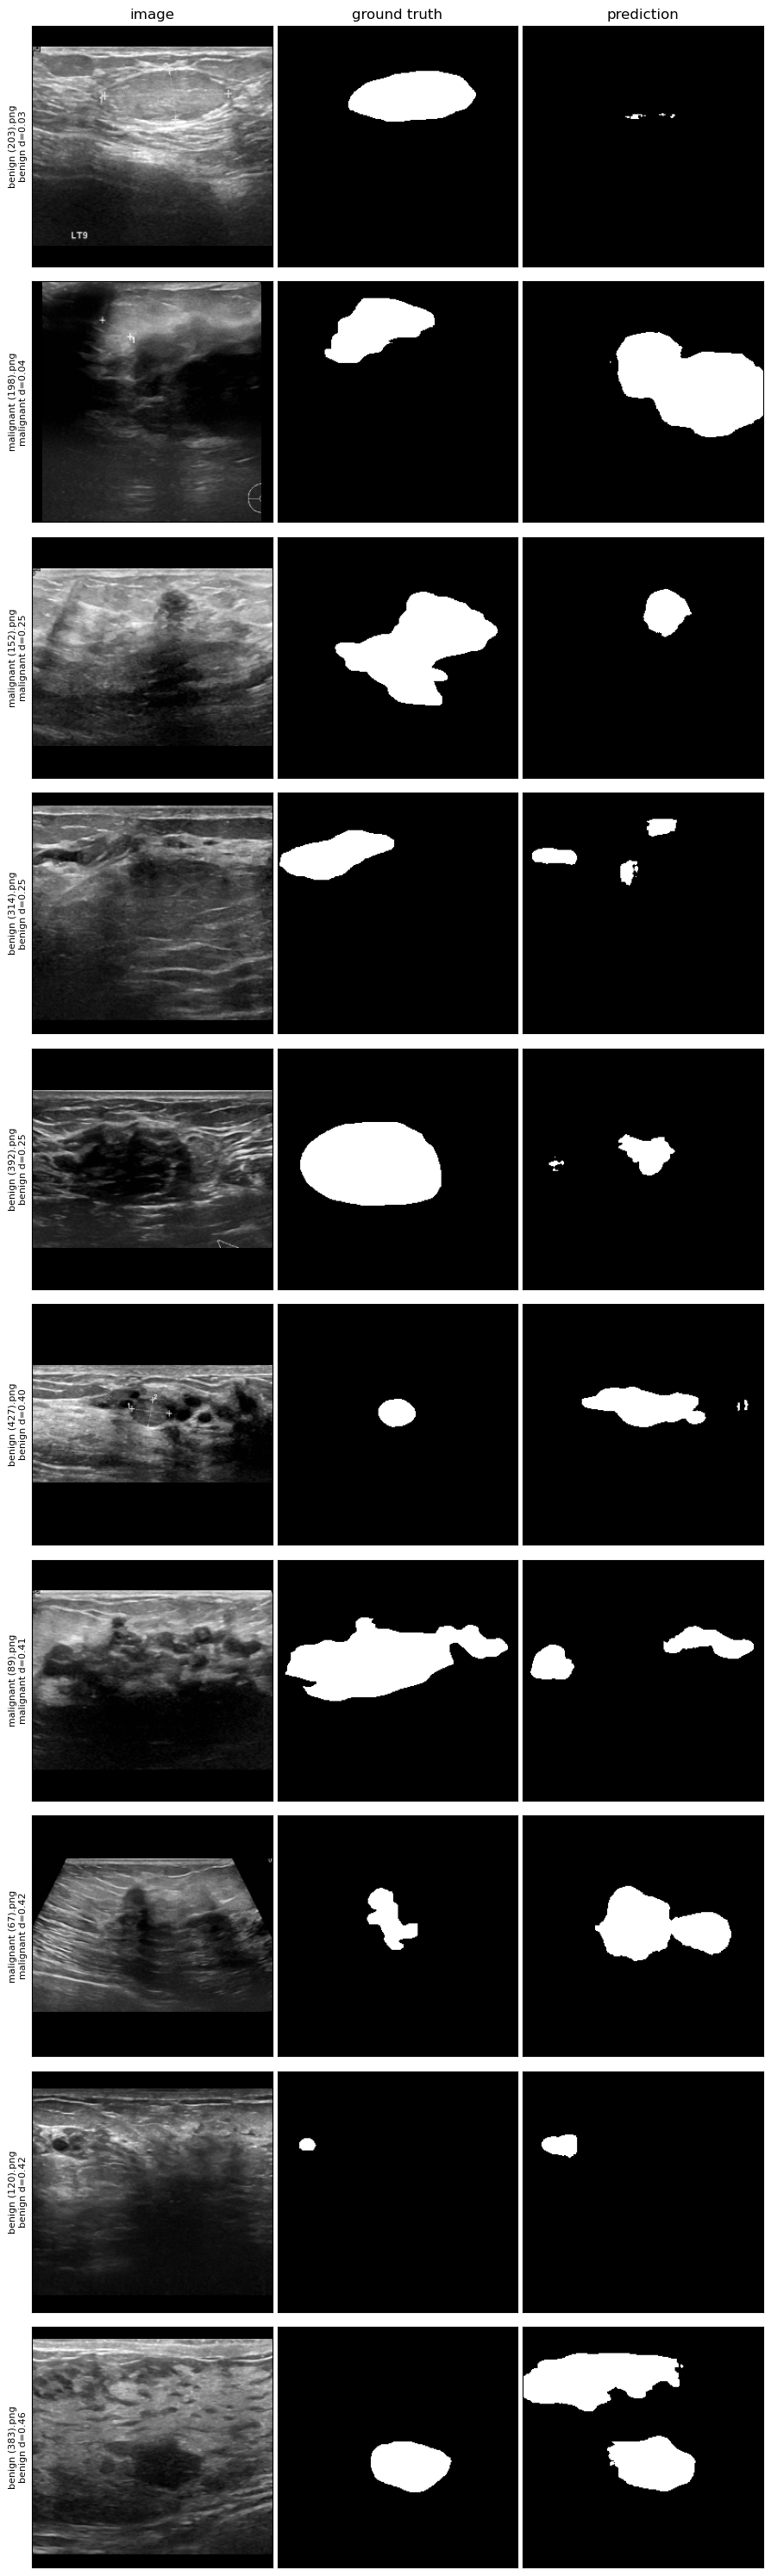

In [80]:
import matplotlib.pyplot as plt

MODEL = final_model     # or struct_model / innovation_model_final — whichever you're reporting

fails = []
for _, r in test_df.iterrows():
    img, mask = load_pair(r)
    prob = tta_predict(MODEL, img)
    d = numpy_dice(mask[..., 0], (prob > 0.5).astype(np.float32))
    if d < 0.50:
        fails.append({'name': os.path.basename(r['image']), 'class': r['class'],
                      'dice': d, 'img': img, 'mask': mask, 'prob': prob})
fails.sort(key=lambda x: x['dice'])

print(f"{len(fails)} images below 0.50:")
for f in fails:
    print(f"  {f['name']:26s} {f['class']:10s} dice={f['dice']:.3f}")

n = len(fails)
fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
if n == 1: axes = axes[None, :]
for i, f in enumerate(fails):
    axes[i,0].imshow(f['img'][...,0], cmap='gray')
    axes[i,0].set_ylabel(f"{f['name']}\n{f['class']} d={f['dice']:.2f}", fontsize=8)
    axes[i,1].imshow(f['mask'][...,0], cmap='gray')
    axes[i,2].imshow((f['prob'] > 0.5), cmap='gray')
    for j in range(3): axes[i,j].set_xticks([]); axes[i,j].set_yticks([])
axes[0,0].set_title('image'); axes[0,1].set_title('ground truth'); axes[0,2].set_title('prediction')
plt.tight_layout(); plt.show()

In [81]:
# ===================== Efficiency measurement: params, sparsity, FLOPs, latency, size =====================
import os, time, json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

CUSTOM = {'dice_coef': dice_coef, 'dice_loss': dice_loss,
          'hybrid_loss': hybrid_loss, 'iou_coef': iou_coef}

def get_flops(model):
    """Total float ops for one forward pass at batch size 1."""
    concrete = tf.function(lambda x: model(x)).get_concrete_function(
        tf.TensorSpec([1, IMG_SIZE, IMG_SIZE, 1], tf.float32))
    frozen, _ = convert_variables_to_constants_v2_as_graph(concrete)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(frozen.graph.as_graph_def(), name='')
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        opts['output'] = 'none'
        prof = tf.compat.v1.profiler.profile(graph=graph, options=opts)
    return prof.total_float_ops

def measure_latency(model, n=30, warmup=5):
    x = np.zeros((1, IMG_SIZE, IMG_SIZE, 1), np.float32)
    for _ in range(warmup):
        _ = model(x, training=False)
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        _ = model(x, training=False)
        ts.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(ts)), float(np.median(ts)), float(np.std(ts))

def sparsity(model):
    tot = zed = 0
    for w in model.get_weights():
        tot += w.size; zed += int((w == 0).sum())
    return zed, tot

def measure(path, tag):
    m = keras.models.load_model(path, custom_objects=CUSTOM, compile=False)
    params   = m.count_params()
    zed, tot = sparsity(m)
    flops    = get_flops(m)
    mean, med, sd = measure_latency(m)
    size_mb  = os.path.getsize(path) / (1024**2)
    keras.backend.clear_session()
    return {'model': tag, 'params': params,
            'nonzero': tot - zed, 'sparsity_pct': 100*zed/tot,
            'gflops': flops/1e9, 'latency_ms_mean': mean,
            'latency_ms_median': med, 'latency_ms_std': sd,
            'file_mb': size_mb}

rows = []
for path, tag in [('benchmark_unet.keras',            'Benchmark (residual U-Net)'),
                  ('innovation_seed42_final.keras',   'Innovation (unpruned)'),
                  ('innovation_seed42_pruned.keras',  'Innovation (pruned)')]:
    if os.path.exists(path):
        rows.append(measure(path, tag))
    else:
        print(f"SKIP (not found): {path}")

print(f"\n{'Model':<30}{'Params':>12}{'Non-zero':>12}{'Spars%':>9}{'GFLOPs':>10}{'Latency ms':>13}{'Size MB':>10}")
print("-"*96)
for r in rows:
    print(f"{r['model']:<30}{r['params']:>12,}{r['nonzero']:>12,}{r['sparsity_pct']:>9.1f}"
          f"{r['gflops']:>10.3f}{r['latency_ms_mean']:>10.1f}±{r['latency_ms_std']:<3.0f}{r['file_mb']:>10.2f}")

json.dump(rows, open('efficiency_measurements.json', 'w'), indent=2)

2026-09-14 09:40:23.120242: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-09-14 09:40:23.126145: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session
2026-09-14 09:40:23.143627: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-14 09:40:23.143642: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-14 09:42:24.775218: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compile


Model                               Params    Non-zero   Spars%    GFLOPs   Latency ms   Size MB
------------------------------------------------------------------------------------------------
Benchmark (residual U-Net)       2,033,025   2,033,025      0.0     6.457     110.4±67       8.06
Innovation (unpruned)              900,569     900,568      0.0     5.798      84.7±100      3.77
Innovation (pruned)                900,569     630,644     30.0     5.798      64.5±77       3.77


In [82]:
import gzip, shutil, os, time, numpy as np
from tensorflow import keras

CUSTOM = {'dice_coef': dice_coef, 'dice_loss': dice_loss,
          'hybrid_loss': hybrid_loss, 'iou_coef': iou_coef}

def latency_robust(model, n=200, warmup=30):
    x = np.zeros((1, IMG_SIZE, IMG_SIZE, 1), np.float32)
    for _ in range(warmup): _ = model(x, training=False)
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); _ = model(x, training=False)
        ts.append((time.perf_counter() - t0) * 1000)
    ts = np.array(ts)
    keep = ts[ts <= np.percentile(ts, 90)]        # drop throttling spikes
    return keep.mean(), np.median(ts), keep.std(), np.percentile(ts, 5), np.percentile(ts, 95)

def gz_mb(path):
    with open(path,'rb') as f_in, gzip.open(path+'.gz','wb',compresslevel=9) as f_out:
        shutil.copyfileobj(f_in, f_out)
    mb = os.path.getsize(path+'.gz')/(1024**2); os.remove(path+'.gz'); return mb

for path, tag in [('benchmark_unet.keras','Benchmark'),
                  ('innovation_seed42_final.keras','Innovation unpruned'),
                  ('innovation_seed42_pruned.keras','Innovation pruned')]:
    m = keras.models.load_model(path, custom_objects=CUSTOM, compile=False)
    mean, med, sd, p5, p95 = latency_robust(m)
    print(f"{tag:<22} latency {mean:6.1f} ms (median {med:5.1f}, sd {sd:4.1f}, "
          f"5-95% {p5:.0f}-{p95:.0f})   raw {os.path.getsize(path)/1024**2:.2f} MB   gzip {gz_mb(path):.2f} MB")
    keras.backend.clear_session()

Benchmark              latency  106.3 ms (median  90.2, sd 46.5, 5-95% 75-463)   raw 8.06 MB   gzip 7.21 MB
Innovation unpruned    latency   53.8 ms (median  51.0, sd 14.3, 5-95% 40-262)   raw 3.77 MB   gzip 3.20 MB
Innovation pruned      latency   48.3 ms (median  44.6, sd 12.9, 5-95% 37-224)   raw 3.77 MB   gzip 2.53 MB
